[![Open In Colab](./images/colab-badge.png)](https://colab.research.google.com/github/MooseNeuro/moose_2026/blob/main/LIF_neuron.ipynb) [![Binder](./images/binder_logo.png)](https://mybinder.org/v2/gh/MooseNeuro/moose_2026/HEAD?labpath=LIF_neuron.ipynb)

# The Leaky Integrate-and-Fire (LIF) neuron in MOOSE

---
# 1. Why the LIF model?

### The problem
Real neurons fire **action potentials** (spikes) using many voltage-gated ion channels. The Hodgkin–Huxley model captures this in detail, but each neuron then needs several differential equations, with fast changing variables that force very small time steps. That is fine for studying *one* neuron, but too slow and too complicated when you want to simulate **thousands to millions of neurons** in a network, or when you only care about **when** neurons spike and not about the exact spike shape.

### The key observation
Action potentials can be **stereotyped**: every spike in a given neuron looks almost the same. So we choose to ignore the *shape* of the spike for the purpose of computational efficiency and focus on the **timing and the number of spikes**. This suggests a simplification:

> **Do not model the spike. Model only what leads up to it, and just record *that* a spike happened.**

### The LIF model
You already know the *subthreshold* behaviour of a neuron: the passive **RC membrane** :

$$\tau_m \frac{dV_m}{dt} = -(V_m - E_m) + R_m I, \qquad \tau_m = R_m C_m$$

The LIF neuron keeps exactly this equation, the **"leaky integrate"** part (the membrane *integrates* the input current and *leaks* charge through $R_m$), and adds three simple rules, the **"fire"** part:

| Rule | What happens | MOOSE field |
|---|---|---|
| **Threshold** | when $V_m$ reaches $V_\text{thresh}$, a spike is registered | `thresh` |
| **Reset** | right after the spike, $V_m$ is set to $V_\text{reset}$ | `vReset` |
| **Refractory period** | for $t_\text{ref}$ after a spike, $V_m$ stays at reset (no new spike) | `refractoryPeriod` |

So: **LIF = passive RC membrane + threshold/reset/refractory rule.**
Everything *below* threshold is plain RC physics.

### What LIF leaves out
No spike shape, no ion channels, no spike-frequency adaptation (the basic version). It is a model of *input → spike times*, not of the biophysics. That is a feature when you want simple, fast, analyzable neurons, and a limitation if you need the biophysics.

---
# 2. Your first LIF neuron in MOOSE

First import the libraries. MOOSE works in **SI units** (ohm, farad, volt, ampere, second), so the code below uses SI units.

In [19]:
# If you need to install them, remove the '#' and run this line once:
# !pip install pymoose ipywidgets matplotlib numpy

import numpy as np                  # arrays and maths
import matplotlib.pyplot as plt     # plotting
from ipywidgets import interact     # sliders
import moose                        # the simulator

Now read the script below **line by line**. It is the complete recipe for an LIF simulation in MOOSE:

1. make a container for the model,
2. create the neuron and set its parameters,
3. create a **current pulse** (the stimulus) and connect it to the neuron,
4. create a **table** to record the membrane potential `Vm`,
5. run the simulation.

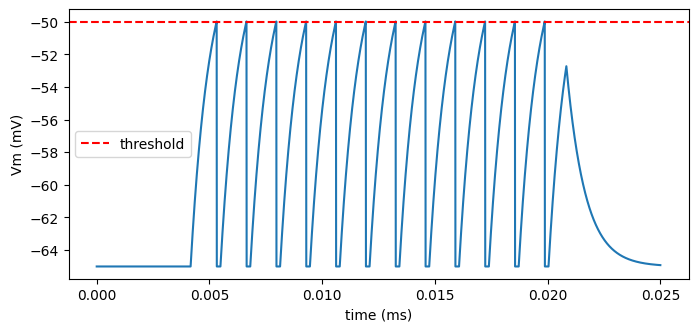

In [20]:
# ---- 1. Clean up any old model, then make a fresh container ----------------
if moose.exists('/model'):
    moose.delete('/model')
moose.Neutral('/model')

# ---- 2. Create the LIF neuron and set its parameters (SI units!) -----------
neuron = moose.LIF('/model/neuron')

neuron.Rm = 100e6               # membrane resistance: 100 MOhm
neuron.Cm = 100e-12             # membrane capacitance: 100 pF
neuron.Em = -65e-3              # resting potential: -65 mV
neuron.initVm = -65e-3          # starting voltage: start at rest

neuron.thresh = -50e-3          # spike threshold: -50 mV
neuron.vReset = -65e-3          # voltage after a spike: -65 mV
neuron.refractoryPeriod = 2e-3  # dead time after a spike: 2 ms

# ---- 3. Create the stimulus: a current step of 200 pA from 50 to 250 ms ----
pulse = moose.PulseGen('/model/pulse')
pulse.delay[0] = 50e-3          # when the pulse starts
pulse.width[0] = 200e-3         # how long it lasts
pulse.level[0] = 200e-12        # its size (current in amperes): 200 pA
moose.connect(pulse, 'output', neuron, 'injectMsg')   # wire pulse -> neuron

# ---- 4. Record the membrane potential --------------------------------------
vm_table = moose.Table('/model/vm_table')
moose.connect(vm_table, 'requestOut', neuron, 'getVm')  # ask the neuron for Vm every time step

# ---- 5. Run ----------------------------------------------------------------
dt = 25e-6                      # simulation time step: 25 microseconds
moose.reinit()                  # reset everything to initial values
moose.start(0.3)                # simulate 0.3 seconds

# ---- Plot ------------------------------------------------------------------
vm = np.array(vm_table.vector)                 # the recorded voltage
t = np.linspace(0, vm_table.dt, len(vm))               # matching time axis
plt.figure(figsize=(8, 3.5))
plt.plot(t * 1000, vm * 1000)                  # convert s -> ms and V -> mV
plt.axhline(-50, color='red', ls='--', label='threshold')
plt.xlabel('time (ms)')
plt.ylabel('Vm (mV)')
plt.legend()
plt.show()

### 🧠 Question 1

Look at the plot.

(a) What happens to $V_m$ when the 200 pA pulse switches on?

(b) What happens every time $V_m$ reaches the red line?

(c) Which of these behaviours would the passive RC model **also** show, and which is new in LIF?

> ✍️ **Your answer** *(double-click to type here, Shift+Enter to finish)*:
>
>

<details>
<summary>💡 Click to reveal the answer</summary>

(a) $V_m$ rises exponentially from rest (−65 mV) towards $E_m + R_m I = -65 + 20 = -45$ mV: it **integrates** the input while **leaking** through $R_m$ (this is the RC behaviour you already know).

(b) When $V_m$ reaches the threshold (−50 mV) it is **reset** to $V_\text{reset}$ (−65 mV) and starts charging again, so the neuron fires **repeatedly**. After the pulse ends, $V_m$ decays back to rest and the spiking stops.

(c) The smooth exponential charging below threshold is exactly the passive RC behaviour. The **threshold-and-reset** (the repeated spiking) is the new ingredient in LIF. A passive RC cell would just keep rising towards −45 mV.

</details>

---
# 3. Explore the parameters

To experiment quickly we wrap the script above in **two functions**. The code inside is the same as before, just reorganized, so you can read it. You do not have to change it.

**`run_lif`** runs the simulation, with the parameters given in friendly units (MΩ, pF, mV, pA, ms) and converts them to SI units for MOOSE.

In [21]:
def run_lif(Rm, Cm, Em, inject, thresh, vReset, refractory):
    '''Run the LIF neuron for 0.3 s with a current step. Returns time (s) and Vm (V).
       Units: Rm in MOhm, Cm in pF, Em/thresh/vReset in mV, inject in pA, refractory in ms.'''

    # fresh model (same steps as in the script above)
    if moose.exists('/model'):
        moose.delete('/model')
    moose.Neutral('/model')

    neuron = moose.LIF('/model/neuron')
    neuron.Rm = Rm * 1e6                    # MOhm -> Ohm
    neuron.Cm = Cm * 1e-12                  # pF   -> F
    neuron.Em = Em * 1e-3                   # mV   -> V
    neuron.initVm = Em * 1e-3
    neuron.thresh = thresh * 1e-3
    neuron.vReset = vReset * 1e-3
    neuron.refractoryPeriod = refractory * 1e-3   # ms -> s

    pulse = moose.PulseGen('/model/pulse')
    pulse.delay[0] = 50e-3
    pulse.width[0] = 200e-3
    pulse.level[0] = inject * 1e-12         # pA -> A
    moose.connect(pulse, 'output', neuron, 'injectMsg')

    vm_table = moose.Table('/model/vm_table')
    moose.connect(vm_table, 'requestOut', neuron, 'getVm')

    moose.reinit()
    moose.start(0.3)

    vm = np.array(vm_table.vector)
    t = np.linspace(0, vm_table.dt, len(vm))
    return t, vm

**`explore`** calls `run_lif`, finds the spikes, plots everything and prints the numbers you will need for your predictions. You only list the parameters you want to *change*; all the others keep the default values stored in `DEFAULTS`.

*How are spikes found?* MOOSE resets $V_m$ after each spike, so a spike shows up as a sudden **drop** in the recorded voltage. We look for those drops.

In [22]:
# The default parameter values (same as in the script above)
DEFAULTS = dict(Rm=100, Cm=100, Em=-65, inject=200, thresh=-50, vReset=-65, refractory=2)


def explore(**changes):
    '''Run the LIF neuron with the defaults, except for the parameters in `changes`.'''
    p = dict(DEFAULTS)            # start from the defaults ...
    p.update(changes)             # ... and replace the ones that were changed

    if p['vReset'] >= p['thresh']:
        print('vReset must be lower than thresh!')
        return

    t, vm = run_lif(**p)

    # A spike = a big sudden drop of Vm (the reset). Find those moments.
    drops = np.where(np.diff(vm) < -0.5 * (p['thresh'] - p['vReset']) * 1e-3)[0]
    spike_times = t[drops + 1]

    # Plot
    plt.figure(figsize=(8, 3.5))
    plt.plot(t * 1000, vm * 1000, label='Vm')
    plt.axhline(p['thresh'], color='red', ls='--', label='threshold')
    plt.axhline(p['Em'], color='green', ls=':', label='rest (Em)')
    plt.plot(spike_times * 1000, [p['thresh']] * len(spike_times), 'rv', label='spike')
    plt.ylim(-100, -20)
    plt.xlabel('time (ms)')
    plt.ylabel('Vm (mV)')
    plt.legend(loc='upper right', ncol=2, fontsize=8)
    plt.show()

    # Numbers to help your predictions
    tau = p['Rm'] * p['Cm'] * 1e-3                       # MOhm * pF = microseconds -> ms
    v_final = p['Em'] + p['Rm'] * p['inject'] * 1e-3     # Em + Rm*I  (MOhm*pA = uV -> mV)
    rheobase = (p['thresh'] - p['Em']) / p['Rm'] * 1e3   # mV / MOhm = nA -> pA
    print(f'time constant tau = {tau:.1f} ms')
    print(f'voltage the neuron is heading for, Em + Rm*I = {v_final:.1f} mV')
    print(f'rheobase (smallest current that makes it fire) = {rheobase:.0f} pA')
    print(f'number of spikes = {len(spike_times)}')

Test it with the defaults. This should look just like your first plot.

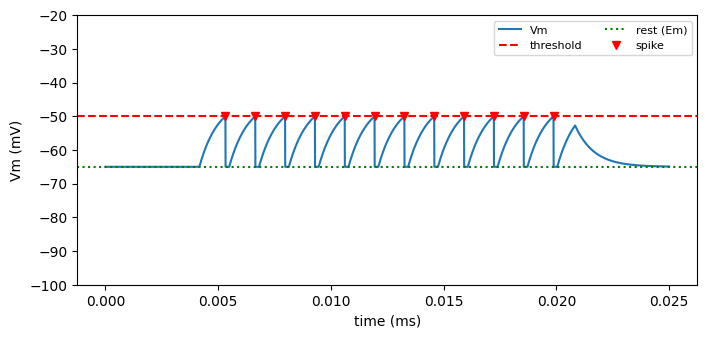

time constant tau = 10.0 ms
voltage the neuron is heading for, Em + Rm*I = -45.0 mV
rheobase (smallest current that makes it fire) = 150 pA
number of spikes = 12


In [23]:
explore()

### How to use the sliders
In the cells below, `interact(explore, inject=(0, 800, 10))` means *"make a slider called `inject` that goes from 0 to 800 in steps of 10, and call `explore` with its value whenever it moves"*. Parameters that are not listed stay at their defaults.

### 3.1 Current and rheobase

In [24]:
interact(explore, inject=(0, 800, 10));

interactive(children=(IntSlider(value=400, description='inject', max=800, step=10), Output()), _dom_classes=('…

### 🧠 Question 2

Neurons have a minimum current needed to fire, called the **rheobase**.

(a) Use the slider to identify the rheobase for the default set of parameters

> ✍️ **Your answer** *(double-click to type here, Shift+Enter to finish)*:
>
>

<details>
<summary>🔎 Hint</summary>

At steady state the voltage stops changing. What value does it settle at, and is it above threshold?

</details>

<details>
<summary>💡 Click to reveal the answer</summary>

(a) 150 pA

</details>

In [25]:
# 🟡 Optional: move the resting potential and the threshold
interact(explore, Em=(-90, -40, 1), thresh=(-60, -30, 1));

interactive(children=(IntSlider(value=-65, description='Em', max=-40, min=-90), IntSlider(value=-45, descripti…

### 3.2 Resistance vs. capacitance
`Rm` and `Cm` both appear in the time constant $\tau_m = R_m C_m$, but they play different roles. Keep `inject` at 200 pA.

In [27]:
interact(explore, Rm=(20, 300, 10), Cm=(20, 500, 10));

interactive(children=(IntSlider(value=160, description='Rm', max=300, min=20, step=10), IntSlider(value=260, d…

### 🧠 Question 3

(a) Set `Cm` to 50, 100 and 400 pF (keep `Rm` at 100 MΩ). Does the firing rate change? (b) Now set `Rm` to 50 MΩ and then 200 MΩ. What happens, and why? (c) In one sentence each: what does `Rm` control and what does `Cm` control?

> ✍️ **Your answer** *(double-click to type here, Shift+Enter to finish)*:
>
>

<details>
<summary>💡 Click to reveal the answer</summary>

(a) The **firing rate changes**: $C_m$ sets $\tau_m$ (5, 10, 40 ms), which is how fast the voltage charges. At 200 pA the rates are about 112, 63 and 17 Hz. **Bigger $C_m$ → slower charging → lower rate.**

(b) $R_m = 50$ MΩ: $V_\infty=-55$ mV, below threshold and the rheobase is 300 pA, so the neuron is **silent**. $R_m=200$ MΩ: $V_\infty=-25$ mV, far above threshold and the rheobase is 75 pA, so it fires **fast**. A larger $R_m$ turns the same current into a larger voltage change, so the cell is more excitable.

(c) **`Rm` sets *how much* the voltage moves per unit current (whether and how strongly the cell fires). `Cm` sets *how fast* the voltage moves (the speed of integration).**

</details>

### 3.3 What happens after the spike: reset

In [28]:
interact(explore, vReset=(-90, -51, 1));

interactive(children=(IntSlider(value=-71, description='vReset', max=-51, min=-90), Output()), _dom_classes=('…

### 🧠 Question 4

Compare `vReset` = −55, −65 (default) and −80 mV at 200 pA. Does the firing rate go up or down in each case?

> ✍️ **Your answer** *(double-click to type here, Shift+Enter to finish)*:
>
>

<details>
<summary>💡 Click to reveal the answer</summary>

After a spike, $V_m$ restarts from $V_\text{reset}$ and must climb back to threshold. The **farther below threshold** the reset is, the **longer the climb** and the **lower the rate**:

* −55 mV (close to threshold) → short climb, **higher rate** (about 112 Hz).
* −65 mV → about 63 Hz.
* −80 mV (hyperpolarized reset, like an afterhyperpolarization) → long climb, **lower rate** (about 47 Hz).

</details>

### 3.4 Dead time: the refractory period
Use a **strong** current (600 pA) so the neuron fires fast.

In [29]:
interact(explore, inject=(0, 800, 10), refractory=(0, 20, 1.0));

interactive(children=(IntSlider(value=400, description='inject', max=800, step=10), FloatSlider(value=10.0, de…

### 🧠 Question 5

Set `inject` to 600 pA and compare `refractory` = 0, 2 and 10 ms. (a) What happens to the firing rate? (b) What is the *maximum* rate the neuron can reach, and which parameter limits it? (c) Why would the refractory period matter far less at 200 pA?

> ✍️ **Your answer** *(double-click to type here, Shift+Enter to finish)*:
>
>

<details>
<summary>💡 Click to reveal the answer</summary>

(a) The rate drops as the refractory period grows: roughly 350 Hz (0 ms), 200 Hz (2 ms) and 80 Hz (10 ms).

(b) Every inter-spike interval is the dead time plus the charging time: $T_\text{ISI} = t_\text{ref} + (\text{charging time})$. At 600 pA the charging time is only about 3 ms, so the dead time dominates and the rate can never exceed about $1/t_\text{ref}$. **The refractory period sets the maximum firing rate.**

(c) At 200 pA the charging time is about 14 ms, much longer than 2 ms, so the dead time is only a small part of the interval. The refractory period does not move the rheobase either.

</details>

### 3.5 Putting it together: the f–I curve  
A neuron's input–output relationship is summarized by its **f–I curve**: firing **rate** against injected **current**. The code below simply loops over many currents, runs the simulation for each, and measures the rate (spikes per second, from the average time between spikes). The grey curve is the default neuron; the blue one uses your slider values.

In [30]:
currents = np.arange(0, 801, 50)          # currents to test, in pA


def firing_rate(**params):
    '''Firing rate (Hz) for the given parameters (uses run_lif from above).'''
    t, vm = run_lif(**params)
    drops = np.where(np.diff(vm) < -0.5 * (params['thresh'] - params['vReset']) * 1e-3)[0]
    spike_times = t[drops + 1]
    if len(spike_times) < 2:
        return 0.0                         # no rate if there are fewer than 2 spikes
    return 1.0 / np.mean(np.diff(spike_times))   # 1 / (average time between spikes)


# The default neuron's f-I curve (computed once)
default_rates = [firing_rate(**dict(DEFAULTS, inject=I)) for I in currents]


def plot_fi(**changes):
    p = dict(DEFAULTS)
    p.update(changes)
    if p['vReset'] >= p['thresh']:
        print('vReset must be lower than thresh!')
        return
    rates = [firing_rate(**dict(p, inject=I)) for I in currents]

    plt.figure(figsize=(7, 4))
    plt.plot(currents, default_rates, 'o-', color='lightgray', label='default parameters')
    plt.plot(currents, rates, 'o-', color='C0', label='your parameters')
    plt.xlabel('injected current (pA)')
    plt.ylabel('firing rate (Hz)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


interact(plot_fi, Rm=(20, 300, 10), Cm=(20, 500, 10), thresh=(-60, -30, 1),
         vReset=(-90, -51, 1), refractory=(0, 20, 1.0));

interactive(children=(IntSlider(value=160, description='Rm', max=300, min=20, step=10), IntSlider(value=260, d…

### 🧠 Question 6

(a) Describe the shape of the default f–I curve: where does it start, and does it keep rising forever? (b) Predict, then test with the sliders: which parameters **shift** the curve left/right, which change its **steepness**, and which sets its **ceiling**?

> ✍️ **Your answer** *(double-click to type here, Shift+Enter to finish)*:
>
>

<details>
<summary>💡 Click to reveal the answer</summary>

(a) The rate is **0 Hz until the rheobase** (150 pA), then rises steeply and then **bends over and flattens** towards a ceiling at high current. Without a refractory period it would keep rising roughly linearly.

(b)
* **Shift (rheobase):** `Rm` (and `Em`, `thresh`, not shown on sliders here), through $(V_\text{thresh}-E_m)/R_m$. `Cm` and `vReset` do **not** shift it.
* **Steepness (gain):** `Cm` (bigger → shallower), `Rm`, and `vReset` (a lower reset → shallower).
* **Ceiling:** the `refractory` period, at about $1/t_\text{ref}$.

</details>

---
# 4. Summary

| Parameter | MOOSE field | What it controls | Effect on rheobase | Effect on firing rate |
|---|---|---|---|---|
| Membrane resistance | `Rm` | how much voltage per unit current | lower as `Rm` ↑ | higher |
| Membrane capacitance | `Cm` | how fast the voltage changes | none | lower as `Cm` ↑ |
| Resting potential | `Em` | where the voltage sits without input | lower as `Em` ↑ | higher |
| Injected current | `inject` | the input drive | (compared against it) | higher |
| Threshold | `thresh` | when a spike is triggered | higher as `thresh` ↑ | lower |
| Reset voltage | `vReset` | where $V_m$ restarts after a spike | none | lower as reset is lowered |
| Refractory period | `refractoryPeriod` | dead time after a spike | none | caps the maximum at ≈ 1/t_ref |

**Take-home message:** an LIF neuron is a passive RC membrane plus a threshold/reset/refractory rule. Below threshold it behaves exactly like the RC model; above it, it turns a steady current into a train of spikes whose rate depends on all the parameters above.